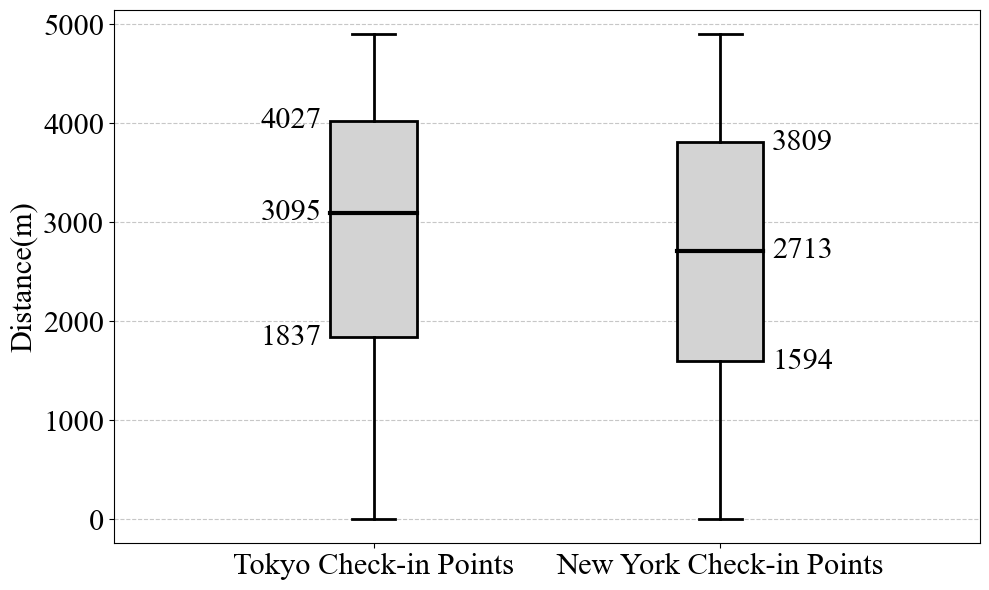

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun'] 
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

ny_distribution = {
    "0-100m": 172828,
    "100-200m": 160078,
    "200-300m": 162042,
    "300-400m": 133451,
    "400-500m": 105220,
    "500-600m": 99621,
    "600-700m": 86969,
    "700-800m": 101051,
    "800-900m": 85936,
    "900-1000m": 86757,
    "1000-1100m": 99893,
    "1100-1200m": 102114,
    "1200-1300m": 111522,
    "1300-1400m": 115481,
    "1400-1500m": 121397,
    "1500-1600m": 132953,
    "1600-1700m": 145646,
    "1700-1800m": 151940,
    "1800-1900m": 138606,
    "1900-2000m": 163794,
    "2000-2100m": 188101,
    "2100-2200m": 159042,
    "2200-2300m": 156423,
    "2300-2400m": 155179,
    "2400-2500m": 181491,
    "2500-2600m": 182051,
    "2600-2700m": 184476,
    "2700-2800m": 197006,
    "2800-2900m": 182461,
    "2900-3000m": 195388,
    "3000-3100m": 204284,
    "3100-3200m": 198127,
    "3200-3300m": 213995,
    "3300-3400m": 212598,
    "3400-3500m": 239094,
    "3500-3600m": 282333,
    "3600-3700m": 246453,
    "3700-3800m": 261654,
    "3800-3900m": 257251,
    "3900-4000m": 238686,
    "4000-4100m": 239570,
    "4100-4200m": 230813,
    "4200-4300m": 244116,
    "4300-4400m": 244164,
    "4400-4500m": 273785,
    "4500-4600m": 262197,
    "4600-4700m": 261594,
    "4700-4800m": 278157,
    "4800-4900m": 256607,
}

tokyo_user_distribution = {
    "0-100m": 40243,
    "100-200m": 56032,
    "200-300m": 81990,
    "300-400m": 104745,
    "400-500m": 125920,
    "500-600m": 148030,
    "600-700m": 164649,
    "700-800m": 188891,
    "800-900m": 207793,
    "900-1000m": 217648,
    "1000-1100m": 230335,
    "1100-1200m": 234342,
    "1200-1300m": 241836,
    "1300-1400m": 254418,
    "1400-1500m": 258392,
    "1500-1600m": 259983,
    "1600-1700m": 256525,
    "1700-1800m": 256564,
    "1800-1900m": 249449,
    "1900-2000m": 242859,
    "2000-2100m": 252380,
    "2100-2200m": 257364,
    "2200-2300m": 254665,
    "2300-2400m": 250745,
    "2400-2500m": 244545,
    "2500-2600m": 243398,
    "2600-2700m": 242226,
    "2700-2800m": 244040,
    "2800-2900m": 253095,
    "2900-3000m": 248790,
    "3000-3100m": 252818,
    "3100-3200m": 252712,
    "3200-3300m": 254888,
    "3300-3400m": 254128,
    "3400-3500m": 256733,
    "3500-3600m": 262614,
    "3600-3700m": 262393,
    "3700-3800m": 265607,
    "3800-3900m": 259804,
    "3900-4000m": 257948,
    "4000-4100m": 263177,
    "4100-4200m": 260898,
    "4200-4300m": 259213,
    "4300-4400m": 258081,
    "4400-4500m": 254687,
    "4500-4600m": 254402,
    "4600-4700m": 252437,
    "4700-4800m": 254660,
    "4800-4900m": 247983,
}

def generate_distance_data(distribution, seed):
    np.random.seed(seed)
    all_distances = []
    
    for label, count in distribution.items():
        distance_range = label.split('-')
        if len(distance_range) == 2:
            start = int(distance_range[0])
            end = int(distance_range[1].replace('m', ''))
            distances = np.random.uniform(start, end, count)
            all_distances.extend(distances)
    
    return np.array(all_distances)

ny_distances = generate_distance_data(ny_distribution, 42)
tokyo_user_distances = generate_distance_data(tokyo_user_distribution, 123)

plt.figure(figsize=(10, 6))

box_plot = plt.boxplot([ny_distances, tokyo_user_distances], 
                       labels=['Tokyo Check-in Points', 'New York Check-in Points'],
                       patch_artist=True,
                       showfliers=True,
                       whis=1.5,
                       widths=0.1,
                       positions=[0.8, 1.2])

for patch in box_plot['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
    patch.set_alpha(1.0)

box_plot['medians'][0].set_color('black')
box_plot['medians'][1].set_color('black')
for median in box_plot['medians']:
    median.set_linewidth(3)

for whisker in box_plot['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(2)
for cap in box_plot['caps']:
    cap.set_color('black')
    cap.set_linewidth(2)
for flier in box_plot['fliers']:
    flier.set_markerfacecolor('black')
    flier.set_markeredgecolor('black')
    flier.set_markersize(4)

plt.ylabel('Distance(m)', fontsize=22)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0.5, 1.5)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

ny_q1 = np.percentile(ny_distances, 25)
ny_median = np.median(ny_distances)
ny_q3 = np.percentile(ny_distances, 75)

tokyo_q1 = np.percentile(tokyo_user_distances, 25)
tokyo_median = np.median(tokyo_user_distances)
tokyo_q3 = np.percentile(tokyo_user_distances, 75)

plt.text(0.74, ny_q1, f'{ny_q1:.0f}', ha='right', va='center', fontsize=22, color='black')
plt.text(0.74, ny_median, f'{ny_median:.0f}', ha='right', va='center', fontsize=22, color='black')
plt.text(0.74, ny_q3, f'{ny_q3:.0f}', ha='right', va='center', fontsize=22, color='black')

plt.text(1.26, tokyo_q1, f'{tokyo_q1:.0f}', ha='left', va='center', fontsize=22, color='black')
plt.text(1.26, tokyo_median, f'{tokyo_median:.0f}', ha='left', va='center', fontsize=22, color='black')
plt.text(1.26, tokyo_q3, f'{tokyo_q3:.0f}', ha='left', va='center', fontsize=22, color='black')

plt.subplots_adjust(left=0.12, right=0.88, top=0.9, bottom=0.15)
plt.tight_layout()
plt.show()



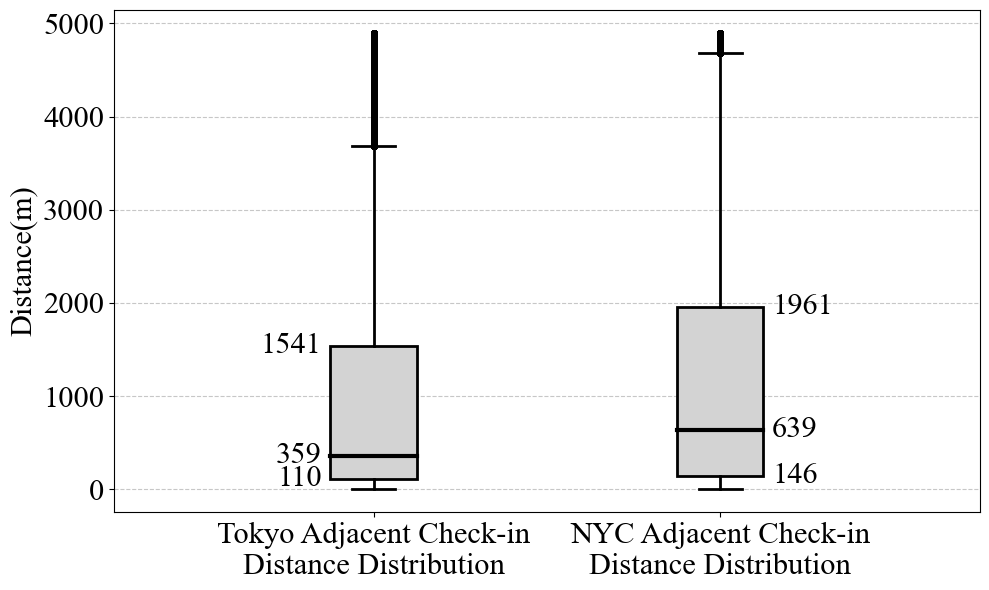

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

tokyo_distribution = {
    "0-100m": 32159,
    "100-200m": 12291,
    "200-300m": 9736,
    "300-400m": 7675,
    "400-500m": 6434,
    "500-600m": 5561,
    "600-700m": 4847,
    "700-800m": 4494,
    "800-900m": 3513,
    "900-1000m": 3331,
    "1000-1100m": 3088,
    "1100-1200m": 2879,
    "1200-1300m": 2691,
    "1300-1400m": 2727,
    "1400-1500m": 2204,
    "1500-1600m": 2209,
    "1600-1700m": 2101,
    "1700-1800m": 2217,
    "1800-1900m": 2024,
    "1900-2000m": 2204,
    "2000-2100m": 1786,
    "2100-2200m": 1701,
    "2200-2300m": 1607,
    "2300-2400m": 1672,
    "2400-2500m": 1512,
    "2500-2600m": 1489,
    "2600-2700m": 1383,
    "2700-2800m": 1446,
    "2800-2900m": 1361,
    "2900-3000m": 1332,
    "3000-3100m": 1291,
    "3100-3200m": 1371,
    "3200-3300m": 1304,
    "3300-3400m": 1363,
    "3400-3500m": 1191,
    "3500-3600m": 1190,
    "3600-3700m": 1185,
    "3700-3800m": 1186,
    "3800-3900m": 1154,
    "3900-4000m": 1065,
    "4000-4100m": 1145,
    "4100-4200m": 1027,
    "4200-4300m": 1117,
    "4300-4400m": 1090,
    "4400-4500m": 931,
    "4500-4600m": 955,
    "4600-4700m": 945,
    "4700-4800m": 1154,
    "4800-4900m": 1014,
}

adjacent_distribution = {
    "0-100m": 41204,
    "100-200m": 22259,
    "200-300m": 16754,
    "300-400m": 11232,
    "400-500m": 7463,
    "500-600m": 5879,
    "600-700m": 4354,
    "700-800m": 4085,
    "800-900m": 2851,
    "900-1000m": 2504,
    "1000-1100m": 2195,
    "1100-1200m": 2073,
    "1200-1300m": 2281,
    "1300-1400m": 2266,
    "1400-1500m": 1827,
    "1500-1600m": 2345,
    "1600-1700m": 2056,
    "1700-1800m": 1923,
    "1800-1900m": 1526,
    "1900-2000m": 1587,
    "2000-2100m": 1812,
    "2100-2200m": 1394,
    "2200-2300m": 1445,
    "2300-2400m": 1277,
    "2400-2500m": 1418,
    "2500-2600m": 1233,
    "2600-2700m": 1112,
    "2700-2800m": 1347,
    "2800-2900m": 1304,
    "2900-3000m": 1208,
    "3000-3100m": 1236,
    "3100-3200m": 1022,
    "3200-3300m": 1182,
    "3300-3400m": 1169,
    "3400-3500m": 1273,
    "3500-3600m": 1452,
    "3600-3700m": 1477,
    "3700-3800m": 1544,
    "3800-3900m": 1004,
    "3900-4000m": 938,
    "4000-4100m": 823,
    "4100-4200m": 1002,
    "4200-4300m": 886,
    "4300-4400m": 877,
    "4400-4500m": 1099,
    "4500-4600m": 1020,
    "4600-4700m": 1164,
    "4700-4800m": 1182,
    "4800-4900m": 1051,
}

def generate_distance_data(distribution, seed):
    np.random.seed(seed)
    all_distances = []
    
    for label, count in distribution.items():
        distance_range = label.split('-')
        if len(distance_range) == 2:
            start = int(distance_range[0])
            end = int(distance_range[1].replace('m', ''))
            distances = np.random.uniform(start, end, count)
            all_distances.extend(distances)
    
    return np.array(all_distances)

tokyo_distances = generate_distance_data(tokyo_distribution, 456)
adjacent_distances = generate_distance_data(adjacent_distribution, 789)

plt.figure(figsize=(10, 6))

box_plot = plt.boxplot([adjacent_distances, tokyo_distances], 
                       labels=['Tokyo Adjacent Check-in\nDistance Distribution', 'NYC Adjacent Check-in\nDistance Distribution'],
                       patch_artist=True,
                       showfliers=True,
                       whis=1.5,
                       widths=0.1,
                       positions=[0.8, 1.2])

for patch in box_plot['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
    patch.set_alpha(1.0)

box_plot['medians'][0].set_color('black')
box_plot['medians'][1].set_color('black')
for median in box_plot['medians']:
    median.set_linewidth(3)

for whisker in box_plot['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(2)
for cap in box_plot['caps']:
    cap.set_color('black')
    cap.set_linewidth(2)
for flier in box_plot['fliers']:
    flier.set_markerfacecolor('black')
    flier.set_markeredgecolor('black')
    flier.set_markersize(4)

plt.ylabel('Distance(m)', fontsize=22)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0.5, 1.5)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

tokyo_q1 = np.percentile(tokyo_distances, 25)
tokyo_median = np.median(tokyo_distances)
tokyo_q3 = np.percentile(tokyo_distances, 75)

adjacent_q1 = np.percentile(adjacent_distances, 25)
adjacent_median = np.median(adjacent_distances)
adjacent_q3 = np.percentile(adjacent_distances, 75)

plt.text(0.74, adjacent_q1, f'{adjacent_q1:.0f}', ha='right', va='center', fontsize=22, color='black')
plt.text(0.74, adjacent_median, f'{adjacent_median:.0f}', ha='right', va='center', fontsize=22, color='black')
plt.text(0.74, adjacent_q3, f'{adjacent_q3:.0f}', ha='right', va='center', fontsize=22, color='black')

plt.text(1.26, tokyo_q1, f'{tokyo_q1:.0f}', ha='left', va='center', fontsize=22, color='black')
plt.text(1.26, tokyo_median, f'{tokyo_median:.0f}', ha='left', va='center', fontsize=22, color='black')
plt.text(1.26, tokyo_q3, f'{tokyo_q3:.0f}', ha='left', va='center', fontsize=22, color='black')

plt.subplots_adjust(left=0.12, right=0.88, top=0.9, bottom=0.15)
plt.tight_layout()
plt.show()
